In [1]:
!wget https://assets.datacamp.com/production/repositories/2085/datasets/fabaa1f1675549d624eb8f5d1bc94e0b11e30a8e/sunnybrook-cardiac-mr.zip

--2025-10-30 17:10:30--  https://assets.datacamp.com/production/repositories/2085/datasets/fabaa1f1675549d624eb8f5d1bc94e0b11e30a8e/sunnybrook-cardiac-mr.zip
Resolviendo assets.datacamp.com (assets.datacamp.com)... 104.18.43.162, 172.64.144.94
Conectando con assets.datacamp.com (assets.datacamp.com)[104.18.43.162]:443... conectado.
Petición HTTP enviada, esperando respuesta... 200 OK
Longitud: 7282711 (6,9M)
Guardando como: ‘sunnybrook-cardiac-mr.zip’

sunnybrook-cardiac- 100%[===================>]   6,95M  2,43MB/s    en 2,9s    

2025-10-30 17:10:34 (2,43 MB/s) - ‘sunnybrook-cardiac-mr.zip’ guardado [7282711/7282711]



In [2]:
!unzip sunnybrook-cardiac-mr.zip -d Data

Archive:  sunnybrook-cardiac-mr.zip
  inflating: Data/SCD2001_000/SCD2001_MR_201.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_202.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_203.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_204.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_205.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_206.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_207.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_208.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_209.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_210.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_211.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_212.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_213.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_214.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_215.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_216.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_217.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_218.dcm  
  inflating: Data/SCD2001_000/SCD2001_MR_219.d

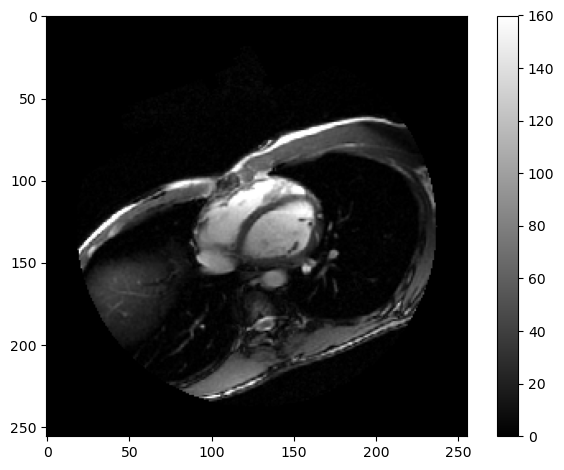

In [3]:
# Importamos todas las librerías que necesitamos
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi
import matplotlib.ticker as ticker
# cargar una imagen
heartbeat= imageio.imread('Data/SCD2001_007/SCD2001_MR_079.dcm')
# Establecer el intervalo de la barra de referencia
min_val = 0
max_val = 160
tick_interval = 20
tick_vals = np.arange(min_val, max_val + tick_interval, tick_interval)
# Graficar la imagen en escala de grises
plt.imshow(heartbeat, vmin=min_val, vmax = max_val, cmap='gray')
colorbar = plt.colorbar()
colorbar.set_ticks(tick_vals)
plt.tight_layout()
plt.show()

In [4]:
# Smooth intensity values
im_filt = ndi.median_filter(heartbeat, size=3)

In [5]:
# Select high-intensity pixels
mask_start = np.where(im_filt>80, 1, 0)
mask = ndi.binary_closing(mask_start)

In [6]:
# Label the objects in "mask"
labels, nlabels = ndi.label(mask)
print('Num. Labels:', nlabels)

Num. Labels: 25


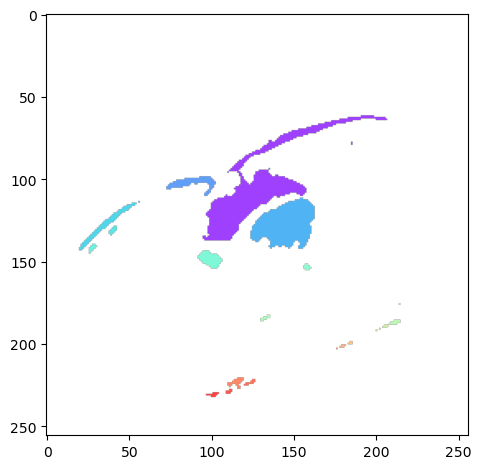

In [7]:
# Create a `labels` overlay
overlay = np.where(labels!=0, labels, np.nan)
# Use imshow to plot the overlay
plt.imshow(overlay, cmap='rainbow', alpha=0.75)
plt.tight_layout()
plt.show()

Num. Labels: 25


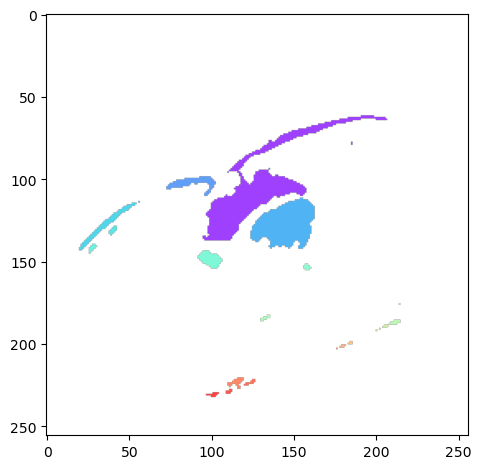

lv_val: 6.0


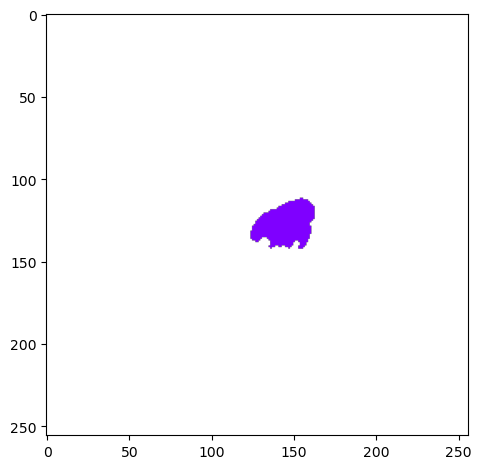

In [8]:
# Select high-intensity pixels
mask_start = np.where(im_filt>80, 1, 0)
mask = ndi.binary_closing(mask_start)
# Label the objects in "mask"
labels, nlabels = ndi.label(mask)
print('Num. Labels:', nlabels)
# Create a `labels` overlay
overlay = np.where(labels!=0, labels, np.nan)
# Use imshow to plot the overlay
plt.imshow(overlay, cmap='rainbow', alpha=0.75)
plt.tight_layout()
plt.show()
# Select left ventricle pixels
lv_val = overlay[128, 128]
print('lv_val:', lv_val)
lv_mask = np.where(labels==lv_val,1,np.nan )
# Use imshow to plot the overlay
plt.imshow(lv_mask, cmap='rainbow')
plt.tight_layout()
plt.show()

In [9]:
# Find bounding box of left ventricle
lv_mask_int = np.where(labels==lv_val, 1, 0).astype(int)
bboxes = ndi.find_objects(lv_mask_int)
print('Number of objects:', len(bboxes))
print('Indices for first box:', bboxes[0])

Number of objects: 1
Indices for first box: (slice(112, 143, None), slice(124, 163, None))


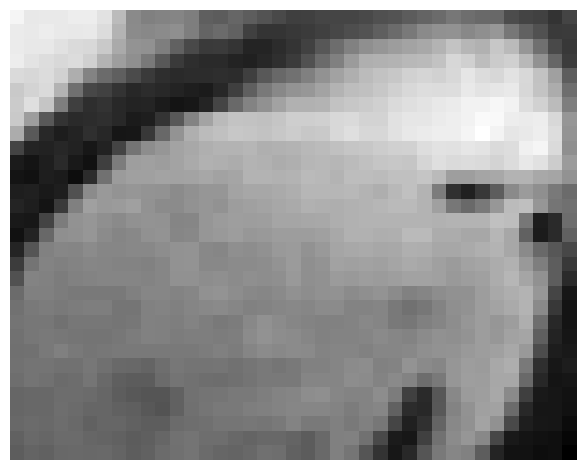

In [10]:
# Crop to the left ventricle (index 0)
im_lv = heartbeat[bboxes[0]]
# Plot the cropped image
plt.imshow(im_lv, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

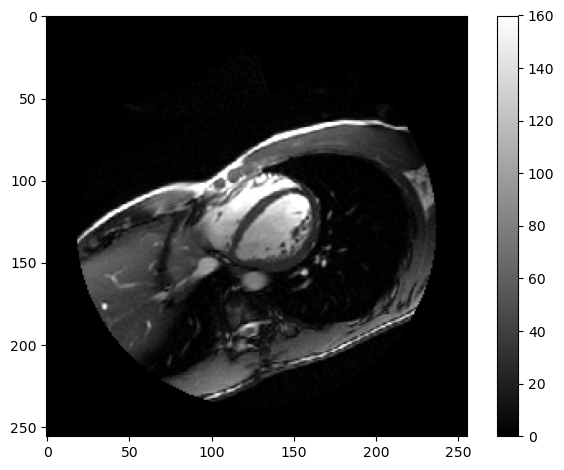

In [11]:
# Importamos todas las librerías que necesitamos
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi
import matplotlib.ticker as ticker
# cargar una imagen
heartbeat= imageio.imread('Data/SCD2001_006/SCD2001_MR_117.dcm')
# Establecer el intervalo de la barra de referencia
min_val = 0
max_val = 160
tick_interval = 20
tick_vals = np.arange(min_val, max_val + tick_interval, tick_interval)
# Graficar la imagen en escala de grises
plt.imshow(heartbeat, vmin=min_val, vmax = max_val, cmap='gray')
colorbar = plt.colorbar()
colorbar.set_ticks(tick_vals)
plt.tight_layout()
plt.show()

In [12]:
# Smooth intensity values
im_filt = ndi.median_filter(heartbeat, size=3)

In [16]:
# Select high-intensity pixels
mask_start = np.where(im_filt>60, 1, 0)
mask = ndi.binary_closing(mask_start)

In [17]:
# Label the objects in "mask"
labels, nlabels = ndi.label(mask)
print('Num. Labels:', nlabels)

Num. Labels: 26


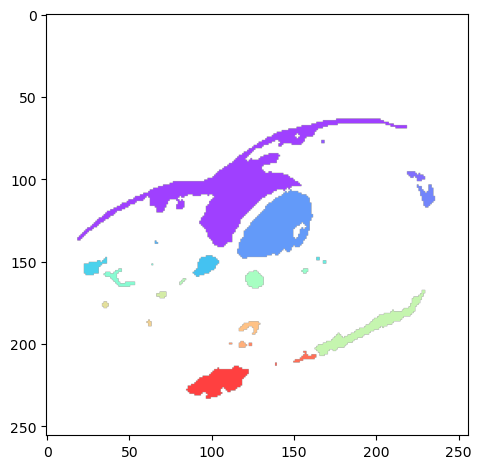

In [18]:
# Create a `labels` overlay
overlay = np.where(labels!=0, labels, np.nan)
# Use imshow to plot the overlay
plt.imshow(overlay, cmap='rainbow', alpha=0.75)
plt.tight_layout()
plt.show()

Num. Labels: 32


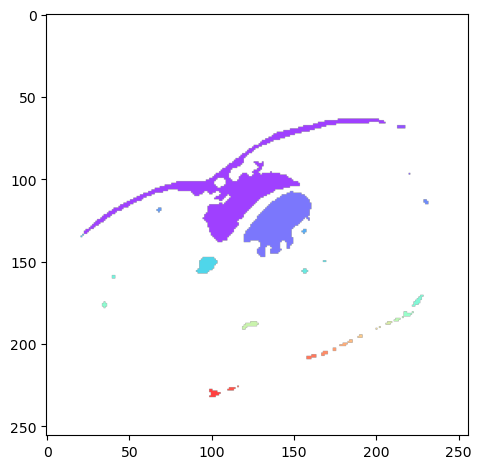

lv_val: 4.0


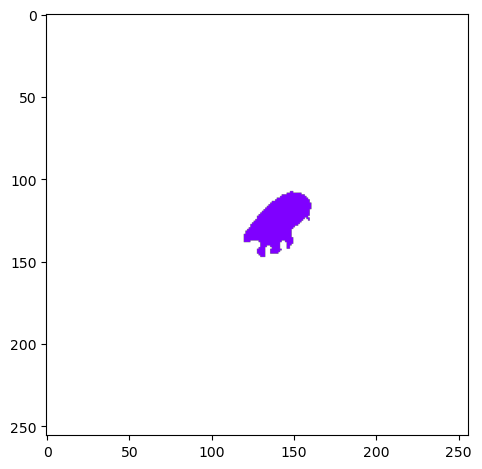

In [19]:
# Select high-intensity pixels
mask_start = np.where(im_filt>80, 1, 0)
mask = ndi.binary_closing(mask_start)
# Label the objects in "mask"
labels, nlabels = ndi.label(mask)
print('Num. Labels:', nlabels)
# Create a `labels` overlay
overlay = np.where(labels!=0, labels, np.nan)
# Use imshow to plot the overlay
plt.imshow(overlay, cmap='rainbow', alpha=0.75)
plt.tight_layout()
plt.show()
# Select left ventricle pixels
lv_val = overlay[128, 128]
print('lv_val:', lv_val)
lv_mask = np.where(labels==lv_val,1,np.nan )
# Use imshow to plot the overlay
plt.imshow(lv_mask, cmap='rainbow')
plt.tight_layout()
plt.show()

In [20]:
# Find bounding box of left ventricle
lv_mask_int = np.where(labels==lv_val, 1, 0).astype(int)
bboxes = ndi.find_objects(lv_mask_int)
print('Number of objects:', len(bboxes))
print('Indices for first box:', bboxes[0])

Number of objects: 1
Indices for first box: (slice(108, 148, None), slice(120, 161, None))


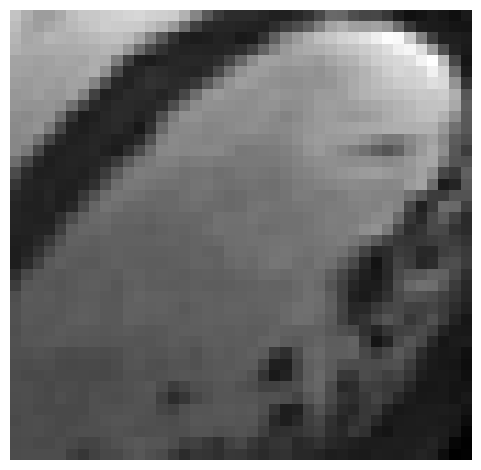

In [21]:
# Crop to the left ventricle (index 0)
im_lv = heartbeat[bboxes[0]]
# Plot the cropped image
plt.imshow(im_lv, cmap='gray')
plt.axis('off')
plt.tight_layout()
plt.show()

continuacion de mediciones

Num. Labels: 26
Objeto 1: (slice(64, 142, None), slice(19, 219, None))
Objeto 2: (slice(77, 79, None), slice(167, 169, None))
Objeto 3: (slice(96, 102, None), slice(219, 230, None))
Objeto 4: (slice(104, 118, None), slice(225, 236, None))
Objeto 5: (slice(107, 149, None), slice(116, 162, None))
Objeto 6: (slice(138, 140, None), slice(66, 68, None))
Objeto 7: (slice(147, 160, None), slice(89, 105, None))
Objeto 8: (slice(148, 159, None), slice(23, 37, None))
Objeto 9: (slice(148, 150, None), slice(164, 166, None))
Objeto 10: (slice(150, 152, None), slice(168, 170, None))
Objeto 11: (slice(152, 153, None), slice(64, 65, None))
Objeto 12: (slice(155, 166, None), slice(35, 54, None))
Objeto 13: (slice(155, 158, None), slice(155, 159, None))
Objeto 14: (slice(156, 167, None), slice(121, 132, None))
Objeto 15: (slice(161, 165, None), slice(81, 85, None))
Objeto 16: (slice(168, 208, None), slice(163, 230, None))
Objeto 17: (slice(169, 173, None), slice(67, 73, None))
Objeto 18: (slice(175, 17

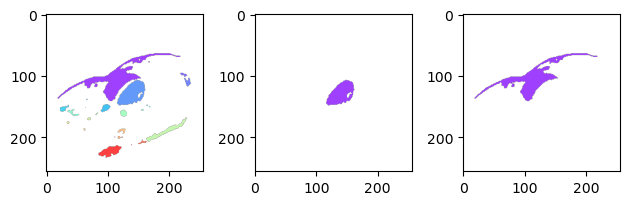

In [2]:
# Importamos todas las librerías que necesitamos
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import scipy.ndimage as ndi
import matplotlib.ticker as ticker

# cargar una imagen
heartbeat= imageio.imread('Data/SCD2001_006/SCD2001_MR_117.dcm')
# Smooth intensity values
im_filt = ndi.median_filter(heartbeat, size=3)
# Select high-intensity pixels
mask_start = np.where(im_filt>60, 1, 0)
mask = ndi.binary_closing(mask_start)
# Label the objects in "mask"
labels, nlabels = ndi.label(mask)
print('Num. Labels:', nlabels)
# Coordenadas de los objetos
bboxes = ndi.find_objects(labels)
for i, bbox in enumerate(bboxes):
    print(f"Objeto {i+1}: {bbox}")
# Create a `labels` overlay
overlay = np.where(labels!=0, labels, np.nan)
#Crear máscaras
lv_mask = np.where(labels==5,1,np.nan )
myo_mask = np.where(labels==1,1,np.nan )
# Use imshow to plot the overlay
fig, axes = plt.subplots(1,3)
axes[0].imshow(overlay, cmap='rainbow', alpha=0.75)
axes[1].imshow(lv_mask, cmap='rainbow', alpha=0.75)
axes[2].imshow(myo_mask, cmap='rainbow', alpha=0.75)
plt.tight_layout()
plt.show()

In [3]:
# cargar una imagen
heartbeat= imageio.imread('Data/SCD2001_006/SCD2001_MR_117.dcm')
# Smooth intensity values
im_filt = ndi.median_filter(heartbeat, size=3)
# Select high-intensity pixels
mask_start = np.where(im_filt>60, 1, 0)
mask = ndi.binary_closing(mask_start)
# Label the objects in "mask"
labels, nlabels = ndi.label(mask)
#Mostrar media de todos los pixeles de la imagen
print('Media de todos los pixeles:', ndi.mean(heartbeat))
#Mostrar media de todos los pixeles etiquetados
print('Media de los pixeles etiquetados:', ndi.mean(heartbeat,labels))
#Etiqueta objeto 1
print('Media de Label 1:', ndi.mean(heartbeat,labels, index=1))
#Etiqueta objeto 5
print('Media de Label 5:', ndi.mean(heartbeat,labels, index=5))
#Etiqueta 1 y 5
print('Media de Label 1 y 5:', ndi.mean(heartbeat,labels, index=[1,5]))

Media de todos los pixeles: 15.834884643554688
Media de los pixeles etiquetados: 104.6169969512195
Media de Label 1: 120.73958738808875
Media de Label 5: 106.74746621621621
Media de Label 1 y 5: [120.73958739 106.74746622]


In [4]:
# Cálculo de varianza de todos los pixeles
var_all = ndi.variance(heartbeat, labels=None, index=None)
print('All pixels:', var_all)
# Cálculo de varianza de los pixeles etiquetados
var_labels = ndi.variance(heartbeat, labels)
print('Labeled pixels:',var_labels)
# Cálculo de varianza de cada objeto
var_objects = ndi.variance(heartbeat, labels, index=[1,5])
print('Ventrículo izquierdo:', var_objects[1])
print('Otro tejido', var_objects[0])

All pixels: 1087.2698102833237
Labeled pixels: 2263.63265317682
Ventrículo izquierdo: 1313.1583550664282
Otro tejido 3008.0415663536937


In [5]:
hist = ndi.histogram(heartbeat,min=0, max=255, bins=256)
obj_hists = ndi.histogram(heartbeat, 0, 255, 256, labels, index=[5,1])
len(obj_hists)

2

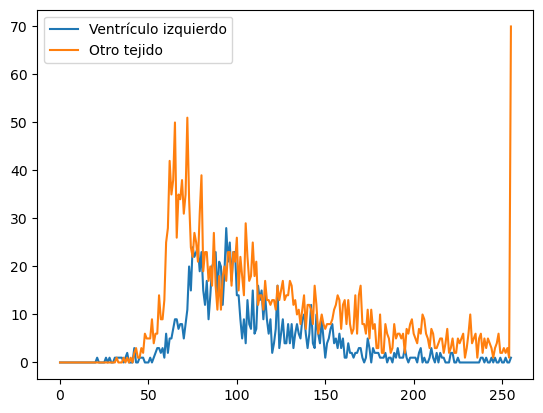

In [7]:
plt.plot(obj_hists[0], label='Ventrículo izquierdo')
plt.plot(obj_hists[1], label='Otro tejido')
plt.legend()
plt.show()

ACTIVIDAD

Número de objetos etiquetados: 26

1. Histograma de TODOS los píxeles creado
2. Histograma de píxeles ETIQUETADOS creado
3. Histograma del VENTRÍCULO IZQUIERDO (objeto 5) creado


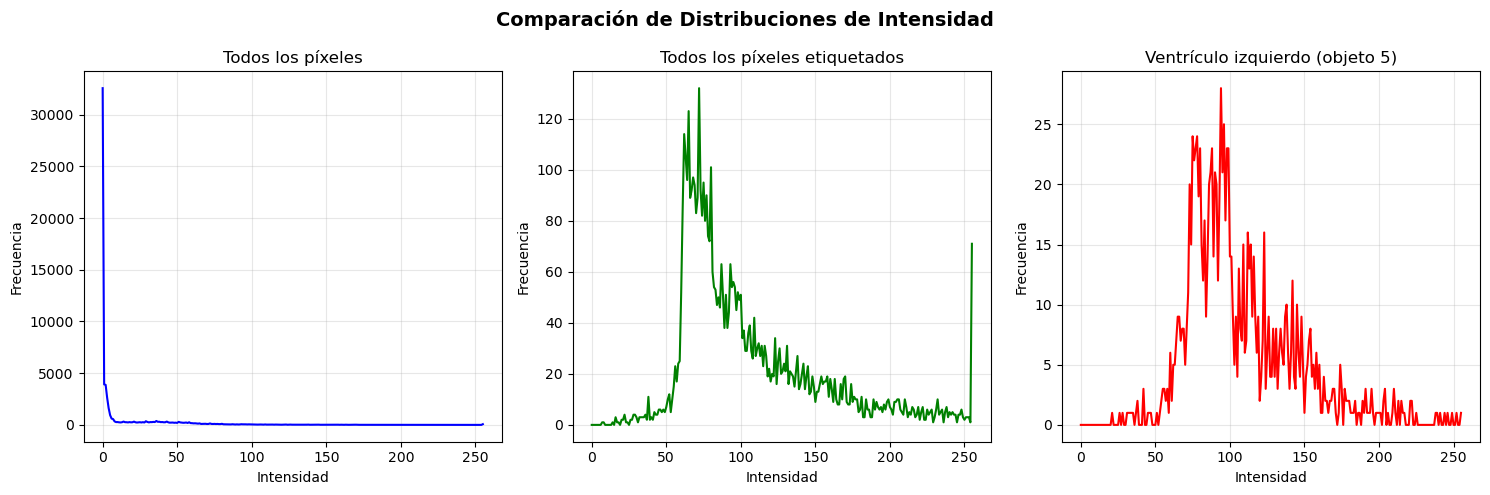

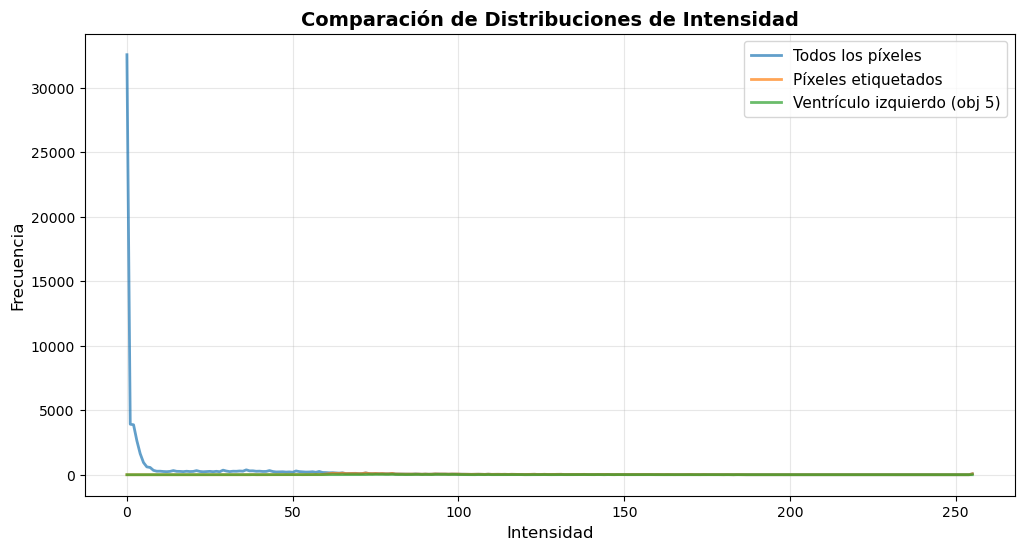


ANÁLISIS DE RESULTADOS

Conjunto                       Media           Varianza       
------------------------------------------------------------
Todos los píxeles              15.83           1087.27        
Píxeles etiquetados            104.62          2263.63        
Ventrículo izquierdo (obj 5)   106.75          1313.16        

INTERPRETACIÓN

1. TODOS LOS PÍXELES:
   - Incluye fondo (valores bajos cercanos a 0)
   - Distribución sesgada hacia valores bajos
   - Media baja debido al fondo negro

2. PÍXELES ETIQUETADOS:
   - Solo incluye tejido segmentado (sin fondo)
   - Media e intensidad más altas
   - Mayor varianza debido a múltiples tipos de tejido

3. VENTRÍCULO IZQUIERDO (Objeto 5):
   - Solo píxeles del ventrículo izquierdo (sangre)
   - Distribución más concentrada (forma de campana)
   - Menor varianza = segmentación más homogénea
   - Indica buena calidad de segmentación



In [9]:
# ============================================================================
# ACTIVIDAD: Comparar distribuciones de intensidad
# ============================================================================

# cargar una imagen
heartbeat = imageio.imread('Data/SCD2001_006/SCD2001_MR_117.dcm')

# Smooth intensity values
im_filt = ndi.median_filter(heartbeat, size=3)

# Select high-intensity pixels
mask_start = np.where(im_filt > 60, 1, 0)
mask = ndi.binary_closing(mask_start)

# Label the objects in "mask"
labels, nlabels = ndi.label(mask)

print('Número de objetos etiquetados:', nlabels)

# ============================================================================
# 1. Histograma de TODOS los píxeles
# ============================================================================
hist_todos = ndi.histogram(heartbeat, min=0, max=255, bins=256)
print('\n1. Histograma de TODOS los píxeles creado')

# ============================================================================
# 2. Histograma de TODOS los píxeles etiquetados
# ============================================================================
hist_etiquetados = ndi.histogram(heartbeat, min=0, max=255, bins=256, 
                                  labels=labels)
print('2. Histograma de píxeles ETIQUETADOS creado')

# ============================================================================
# 3. Histograma del ventrículo izquierdo (objeto 5)
# ============================================================================
hist_ventriculo = ndi.histogram(heartbeat, min=0, max=255, bins=256, 
                                 labels=labels, index=5)
print('3. Histograma del VENTRÍCULO IZQUIERDO (objeto 5) creado')

# ============================================================================
# VISUALIZACIÓN COMPARATIVA
# ============================================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Histograma 1: Todos los píxeles
axes[0].plot(hist_todos, color='blue')
axes[0].set_title('Todos los píxeles')
axes[0].set_xlabel('Intensidad')
axes[0].set_ylabel('Frecuencia')
axes[0].grid(True, alpha=0.3)

# Histograma 2: Píxeles etiquetados
axes[1].plot(hist_etiquetados, color='green')
axes[1].set_title('Todos los píxeles etiquetados')
axes[1].set_xlabel('Intensidad')
axes[1].set_ylabel('Frecuencia')
axes[1].grid(True, alpha=0.3)

# Histograma 3: Ventrículo izquierdo
axes[2].plot(hist_ventriculo, color='red')
axes[2].set_title('Ventrículo izquierdo (objeto 5)')
axes[2].set_xlabel('Intensidad')
axes[2].set_ylabel('Frecuencia')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Comparación de Distribuciones de Intensidad', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# COMPARACIÓN SUPERPUESTA (Todos en un mismo gráfico)
# ============================================================================
plt.figure(figsize=(12, 6))
plt.plot(hist_todos, label='Todos los píxeles', alpha=0.7, linewidth=2)
plt.plot(hist_etiquetados, label='Píxeles etiquetados', alpha=0.7, linewidth=2)
plt.plot(hist_ventriculo, label='Ventrículo izquierdo (obj 5)', alpha=0.7, linewidth=2)
plt.xlabel('Intensidad', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.title('Comparación de Distribuciones de Intensidad', fontsize=14, fontweight='bold')
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================================
# ESTADÍSTICAS COMPARATIVAS
# ============================================================================
print("\n" + "="*70)
print("ANÁLISIS DE RESULTADOS")
print("="*70)

# Estadísticas de cada conjunto
media_todos = ndi.mean(heartbeat)
media_etiquetados = ndi.mean(heartbeat, labels)
media_ventriculo = ndi.mean(heartbeat, labels, index=5)

var_todos = ndi.variance(heartbeat)
var_etiquetados = ndi.variance(heartbeat, labels)
var_ventriculo = ndi.variance(heartbeat, labels, index=5)

print(f"\n{'Conjunto':<30} {'Media':<15} {'Varianza':<15}")
print("-"*60)
print(f"{'Todos los píxeles':<30} {media_todos:<15.2f} {var_todos:<15.2f}")
print(f"{'Píxeles etiquetados':<30} {media_etiquetados:<15.2f} {var_etiquetados:<15.2f}")
print(f"{'Ventrículo izquierdo (obj 5)':<30} {media_ventriculo:<15.2f} {var_ventriculo:<15.2f}")

print("\n" + "="*70)
print("INTERPRETACIÓN")
print("="*70)
print("""
1. TODOS LOS PÍXELES:
   - Incluye fondo (valores bajos cercanos a 0)
   - Distribución sesgada hacia valores bajos
   - Media baja debido al fondo negro

2. PÍXELES ETIQUETADOS:
   - Solo incluye tejido segmentado (sin fondo)
   - Media e intensidad más altas
   - Mayor varianza debido a múltiples tipos de tejido

3. VENTRÍCULO IZQUIERDO (Objeto 5):
   - Solo píxeles del ventrículo izquierdo (sangre)
   - Distribución más concentrada (forma de campana)
   - Menor varianza = segmentación más homogénea
   - Indica buena calidad de segmentación
""")

print("="*70)